# Regresión Lineal Multivariable con PyTorch
### Dataset: House Sales in King County, USA
**Laboratorio:** Inteligencia Artificial I  
**Objetivo:** Predecir el precio de una casa usando una Red Neuronal en PyTorch,  
aplicando Dataset, DataLoader y Checkpoints sobre el modelo de regresión multivariable  
desarrollado en laboratorios anteriores.

---
## Contenido
1. Importaciones y configuración del dispositivo
2. Carga y exploración del dataset
3. Selección de características y normalización
4. Clase Dataset personalizada + DataLoader
5. Definición de la Red Neuronal (regresión)
6. Entrenamiento con checkpoints
7. Evaluación del modelo
8. Guardar y cargar el modelo entrenado
9. Predicción de precio de una casa nueva


## 1. Importaciones y Configuración

In [1]:
# ─── Librerías principales ───────────────────────────────────────────────────
import torch                          # Framework principal de Deep Learning
import torch.nn as nn                 # Módulo para construir redes neuronales
import numpy as np                    # Operaciones matemáticas con arrays
import pandas as pd                   # Lectura y manipulación del archivo CSV
import matplotlib.pyplot as plt       # Visualización de gráficas
from sklearn.model_selection import train_test_split  # Dividir datos en train/test
from sklearn.preprocessing import StandardScaler      # Normalización de características
from sklearn.metrics import mean_squared_error, r2_score  # Métricas de evaluación

# ─── Configuración del dispositivo ───────────────────────────────────────────
# Si hay una GPU disponible la usamos, sino entrenamos en CPU
# En regresión con tablas de datos, CPU suele ser suficiente
device = "cuda" if torch.cuda.is_available() else "cpu"
print(f"Dispositivo disponible: {device}")

Dispositivo disponible: cpu


## 2. Carga y Exploración del Dataset
El dataset contiene **21,613 ventas de casas** en King County (Seattle, USA) con 21 variables.

In [2]:
# ─── Carga del archivo CSV ────────────────────────────────────────────────────
# Ajustá la ruta si tu archivo está en otra carpeta
df = pd.read_csv('kc_house_data.csv')

# Mostramos cuántas filas y columnas tiene el dataset
print(f"Filas: {df.shape[0]} | Columnas: {df.shape[1]}")
print(f"\nColumnas disponibles:")
print(df.columns.tolist())

Filas: 21613 | Columnas: 21

Columnas disponibles:
['id', 'date', 'price', 'bedrooms', 'bathrooms', 'sqft_living', 'sqft_lot', 'floors', 'waterfront', 'view', 'condition', 'grade', 'sqft_above', 'sqft_basement', 'yr_built', 'yr_renovated', 'zipcode', 'lat', 'long', 'sqft_living15', 'sqft_lot15']


In [3]:
# ─── Vista previa de los primeros registros ──────────────────────────────────
# Vemos cómo lucen los datos: cada fila es una venta, cada columna una característica
df.head()

,id,date,price,bedrooms,bathrooms,sqft_living,sqft_lot,floors,waterfront,view,...,grade,sqft_above,sqft_basement,yr_built,yr_renovated,zipcode,lat,long,sqft_living15,sqft_lot15
0,7129300520,20141013T000000,221900.0,3,1.00,1180,5650,1.0,0,0,...,7,1180,0,1955,0,98178,47.5112,-122.257,1340,5650
1,6414100192,20141209T000000,538000.0,3,2.25,2570,7242,2.0,0,0,...,7,2170,400,1951,1991,98125,47.7210,-122.319,1690,7639
2,5631500400,20150225T000000,180000.0,2,1.00,770,10000,1.0,0,0,...,6,770,0,1933,0,98028,47.7379,-122.233,2720,8062
3,2487200875,20141209T000000,604000.0,4,3.00,1960,5000,1.0,0,0,...,7,1050,910,1965,0,98136,47.5208,-122.393,1360,5000
4,1954400510,20150218T000000,510000.0,3,2.00,1680,8080,1.0,0,0,...,8,1680,0,1987,0,98074,47.6168,-122.045,1800,7503


In [4]:
# ─── Estadísticas descriptivas ───────────────────────────────────────────────
# Nos da media, desviación estándar, mínimo y máximo de cada columna numérica
# Esto es importante para entender la escala de los datos antes de normalizar
df.describe()

,id,price,bedrooms,bathrooms,sqft_living,sqft_lot,floors,waterfront,view,condition,grade,sqft_above,sqft_basement,yr_built,yr_renovated,zipcode,lat,long,sqft_living15,sqft_lot15
count,2.161300e+04,2.161300e+04,21613.000000,21613.000000,21613.000000,2.161300e+04,21613.000000,21613.000000,21613.000000,21613.000000,21613.000000,21613.000000,21613.000000,21613.000000,21613.000000,21613.000000,21613.000000,21613.000000,21613.000000,21613.000000
mean,4.580302e+09,5.400881e+05,3.370842,2.114757,2079.899736,1.510697e+04,1.494309,0.007542,0.234303,3.409430,7.656873,1788.390691,291.509045,1971.005136,84.402258,98077.939805,47.560053,-122.213896,1986.552492,12768.455652
std,2.876566e+09,3.671272e+05,0.930062,0.770163,918.440897,4.142051e+04,0.539989,0.086517,0.766318,0.650743,1.175459,828.090978,442.575043,29.373411,401.679240,53.505026,0.138564,0.140828,685.391304,27304.179631
min,1.000102e+06,7.500000e+04,0.000000,0.000000,290.000000,5.200000e+02,1.000000,0.000000,0.000000,1.000000,1.000000,290.000000,0.000000,1900.000000,0.000000,98001.000000,47.155900,-122.519000,399.000000,651.000000
25%,2.123049e+09,3.219500e+05,3.000000,1.750000,1427.000000,5.040000e+03,1.000000,0.000000,0.000000,3.000000,7.000000,1190.000000,0.000000,1951.000000,0.000000,98033.000000,47.471000,-122.328000,1490.000000,5100.000000
50%,3.904930e+09,4.500000e+05,3.000000,2.250000,1910.000000,7.618000e+03,1.500000,0.000000,0.000000,3.000000,7.000000,1560.000000,0.000000,1975.000000,0.000000,98065.000000,47.571800,-122.230000,1840.000000,7620.000000
75%,7.308900e+09,6.450000e+05,4.000000,2.500000,2550.000000,1.068800e+04,2.000000,0.000000,0.000000,4.000000,8.000000,2210.000000,560.000000,1997.000000,0.000000,98118.000000,47.678000,-122.125000,2360.000000,10083.000000
max,9.900000e+09,7.700000e+06,33.000000,8.000000,13540.000000,1.651359e+06,3.500000,1.000000,4.000000,5.000000,13.000000,9410.000000,4820.000000,2015.000000,2015.000000,98199.000000,47.777600,-121.315000,6210.000000,871200.000000


In [5]:
# ─── Verificar si hay valores nulos ──────────────────────────────────────────
# Los valores nulos rompen el entrenamiento, por eso siempre verificamos
nulos = df.isnull().sum()
print("Valores nulos por columna:")
print(nulos[nulos > 0] if nulos.sum() > 0 else "No hay valores nulos ✔")

Valores nulos por columna:
No hay valores nulos ✔


## 3. Selección de Características y Normalización
Elegimos las variables más relevantes para predecir el precio. Aplicamos la misma lógica del laboratorio anterior pero usando `sklearn` para normalizar.

In [6]:
# ─── Selección de características (features) ─────────────────────────────────
# Elegimos columnas numéricas que tienen correlación con el precio
# Descartamos: id (no aporta info), date (texto), zipcode/lat/long (geográficas)
features = [
    'bedrooms',       # número de habitaciones
    'bathrooms',      # número de baños
    'sqft_living',    # metros cuadrados de vivienda (el más importante)
    'sqft_lot',       # metros cuadrados del terreno
    'floors',         # número de pisos
    'waterfront',     # vista al agua (0 o 1)
    'view',           # calidad de la vista (0-4)
    'condition',      # condición general (1-5)
    'grade',          # calidad de construcción (1-13)
    'sqft_above',     # metros cuadrados sobre el suelo
    'sqft_basement',  # metros cuadrados del sótano
    'yr_built',       # año de construcción
    'yr_renovated',   # año de renovación (0 si nunca fue renovada)
]

# Variable objetivo: lo que queremos predecir
target = 'price'

# Separamos X (características) e y (precio)
X = df[features].values   # matriz de características → numpy array
y = df[target].values     # vector de precios → numpy array

print(f"Shape de X (características): {X.shape}")   # (21613, 13)
print(f"Shape de y (precios):         {y.shape}")    # (21613,)
print(f"\nRango de precios: ${y.min():,.0f} - ${y.max():,.0f}")

Shape de X (características): (21613, 13)
Shape de y (precios):         (21613,)

Rango de precios: $75,000 - $7,700,000


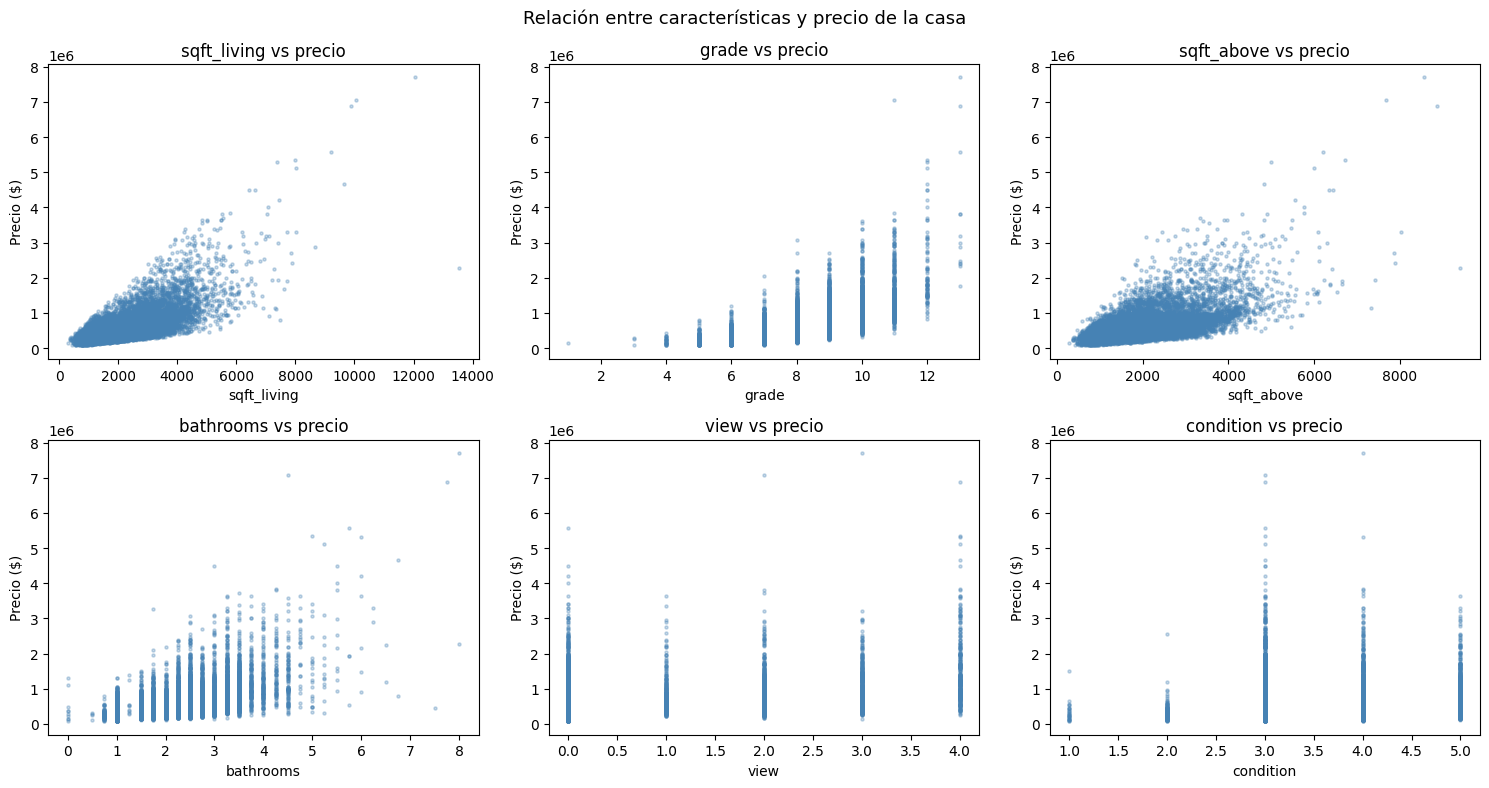

In [7]:
# ─── Visualización: correlación de características con el precio ─────────────
# Una gráfica rápida para ver qué variable tiene más relación con el precio
fig, axes = plt.subplots(2, 3, figsize=(15, 8))
axes = axes.flatten()

# Mostramos las 6 características más relevantes
top_features = ['sqft_living', 'grade', 'sqft_above', 'bathrooms', 'view', 'condition']
for i, feat in enumerate(top_features):
    axes[i].scatter(df[feat], df['price'], alpha=0.3, s=5, color='steelblue')
    axes[i].set_xlabel(feat)
    axes[i].set_ylabel('Precio ($)')
    axes[i].set_title(f'{feat} vs precio')

plt.suptitle('Relación entre características y precio de la casa', fontsize=13)
plt.tight_layout()
plt.show()

In [8]:
# ─── División en conjunto de entrenamiento y prueba ──────────────────────────
# 80% para entrenar la red, 20% para evaluar qué tan bien generaliza
# random_state=42 fija la semilla para que sea reproducible (siempre el mismo split)
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,       # 20% para test
    random_state=42      # semilla para reproducibilidad
)

print(f"Entrenamiento: {X_train.shape[0]} muestras")
print(f"Prueba:        {X_test.shape[0]} muestras")

Entrenamiento: 17290 muestras
Prueba:        4323 muestras


In [9]:
# ─── Normalización de características (StandardScaler) ───────────────────────
# Igual que la función normalizarCaracteristicas() del lab anterior
# Escala cada columna para que tenga media=0 y desviación estándar=1
# Esto es CRÍTICO para que el descenso de gradiente converja bien
# Si no normalizamos, variables como sqft_living (miles) dominarían sobre condition (1-5)

scaler_X = StandardScaler()    # scaler para las características
scaler_y = StandardScaler()    # scaler para el precio (también lo normalizamos)

# Fit solo en train (nunca en test, para no hacer trampa)
X_train_norm = scaler_X.fit_transform(X_train)
X_test_norm  = scaler_X.transform(X_test)      # solo transform, no fit

# Normalizamos y también (necesita shape 2D para sklearn)
y_train_norm = scaler_y.fit_transform(y_train.reshape(-1, 1)).flatten()
y_test_norm  = scaler_y.transform(y_test.reshape(-1, 1)).flatten()

print(f"Media de X_train normalizado: {X_train_norm.mean(axis=0).round(4)}")
print(f"Std  de X_train normalizado:  {X_train_norm.std(axis=0).round(4)}")

Media de X_train normalizado: [-0. -0. -0. -0.  0. -0.  0.  0. -0. -0. -0. -0. -0.]
Std  de X_train normalizado:  [1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1.]


## 4. Clase Dataset Personalizada + DataLoader
Aplicamos el patrón del cuadernillo 03: creamos una clase `Dataset` propia para el CSV y usamos `DataLoader` para iterar en mini-batches.

In [10]:
# ─── Clase Dataset personalizada para datos tabulares (CSV) ──────────────────
# Hereda de torch.utils.data.Dataset (cuadernillo 03)
# Debemos implementar 3 métodos obligatorios: __init__, __len__, __getitem__

class HousePriceDataset(torch.utils.data.Dataset):

    def __init__(self, X, y):
        """
        Constructor: recibe arrays numpy y los convierte a tensores de PyTorch
        X: matriz de características normalizadas  → float32 (la red espera floats)
        y: vector de precios normalizados          → float32
        """
        # Convertimos numpy arrays a tensores y los movemos al dispositivo (GPU/CPU)
        self.X = torch.tensor(X, dtype=torch.float32).to(device)
        self.y = torch.tensor(y, dtype=torch.float32).to(device)

    def __len__(self):
        """
        Retorna la cantidad total de muestras en el dataset
        El DataLoader usa esto para saber cuántos batches crear
        """
        return len(self.X)

    def __getitem__(self, idx):
        """
        Retorna una muestra específica dado su índice
        El DataLoader llama a este método para construir cada batch
        """
        return self.X[idx], self.y[idx]


# ─── Instanciar datasets de entrenamiento y prueba ───────────────────────────
dataset_train = HousePriceDataset(X_train_norm, y_train_norm)
dataset_test  = HousePriceDataset(X_test_norm,  y_test_norm)

print(f"Dataset train: {len(dataset_train)} muestras")
print(f"Dataset test:  {len(dataset_test)} muestras")

# Verificamos que un elemento tenga la forma correcta
x_muestra, y_muestra = dataset_train[0]
print(f"\nShape de una muestra X: {x_muestra.shape}")  # (13,) → 13 características
print(f"Valor de y (precio normalizado): {y_muestra:.4f}")

Dataset train: 17290 muestras
Dataset test:  4323 muestras

Shape de una muestra X: torch.Size([13])
Valor de y (precio normalizado): -0.5886


In [11]:
# ─── DataLoader: gestiona la iteración en mini-batches ───────────────────────
# batch_size=64: procesa 64 casas a la vez en cada paso del entrenamiento
# shuffle=True en train: mezcla los datos en cada epoch para mejor generalización
# shuffle=False en test: no necesitamos mezclar para evaluar

BATCH_SIZE = 64   # número de muestras por mini-batch

dataloader_train = torch.utils.data.DataLoader(
    dataset_train,
    batch_size=BATCH_SIZE,
    shuffle=True     # mezclar en cada epoch → evita que el modelo aprenda el orden
)

dataloader_test = torch.utils.data.DataLoader(
    dataset_test,
    batch_size=BATCH_SIZE,
    shuffle=False    # para evaluación no mezclamos
)

# Verificamos el shape de un batch completo
x_batch, y_batch = next(iter(dataloader_train))
print(f"Shape de un batch X: {x_batch.shape}")  # (64, 13) → 64 casas, 13 características
print(f"Shape de un batch y: {y_batch.shape}")  # (64,)    → 64 precios

Shape de un batch X: torch.Size([64, 13])
Shape de un batch y: torch.Size([64])


## 5. Definición de la Red Neuronal para Regresión
En el lab anterior usamos gradiente manual y ecuación normal. Ahora lo reemplazamos por una red neuronal en PyTorch usando `torch.nn.Module` (cuadernillo 02).

In [12]:
# ─── Red Neuronal para Regresión (hereda de torch.nn.Module) ─────────────────
# A diferencia de clasificación (que termina con Softmax),
# en regresión la capa final tiene UNA sola salida sin función de activación
# porque queremos predecir un número continuo (el precio)

class RedRegresion(nn.Module):

    def __init__(self, n_entradas, n_ocultas_1=128, n_ocultas_2=64, n_ocultas_3=32):
        """
        Constructor de la red neuronal
        n_entradas:    número de características de entrada (13 en nuestro caso)
        n_ocultas_1/2/3: neuronas en cada capa oculta
        """
        # Llamamos al constructor de la clase madre (obligatorio en PyTorch)
        super(RedRegresion, self).__init__()

        # ── Capas de la red ──────────────────────────────────────────────────
        # Capa 1: entrada → primera capa oculta
        self.capa1 = nn.Linear(n_entradas, n_ocultas_1)

        # Capa 2: primera → segunda capa oculta
        self.capa2 = nn.Linear(n_ocultas_1, n_ocultas_2)

        # Capa 3: segunda → tercera capa oculta
        self.capa3 = nn.Linear(n_ocultas_2, n_ocultas_3)

        # Capa de salida: tercera oculta → 1 valor (el precio predicho)
        self.salida = nn.Linear(n_ocultas_3, 1)

        # ── Función de activación ────────────────────────────────────────────
        # ReLU: f(x) = max(0, x) → introduce no linealidad entre capas
        # Sin funciones de activación, la red sería solo una regresión lineal
        self.relu = nn.ReLU()

        # ── Regularización: Dropout ──────────────────────────────────────────
        # Durante el entrenamiento, apaga neuronas aleatoriamente con prob 0.2
        # Esto evita el sobreajuste (overfitting): que la red memorice los datos
        self.dropout = nn.Dropout(p=0.2)

    def forward(self, x):
        """
        Define cómo fluyen los datos a través de la red (propagación hacia adelante)
        PyTorch llama a este método automáticamente cuando hacemos model(x)
        """
        # Cada capa aplica: transformación lineal → ReLU → Dropout
        x = self.dropout(self.relu(self.capa1(x)))
        x = self.dropout(self.relu(self.capa2(x)))
        x = self.dropout(self.relu(self.capa3(x)))

        # La capa de salida NO tiene activación (regresión = valor continuo)
        x = self.salida(x)

        # squeeze(-1) elimina la dimensión extra: (batch, 1) → (batch,)
        return x.squeeze(-1)


# ─── Instanciar el modelo y moverlo al dispositivo ───────────────────────────
N_FEATURES = X_train_norm.shape[1]   # 13 características
modelo = RedRegresion(n_entradas=N_FEATURES).to(device)

# Mostramos la arquitectura completa de la red
print(modelo)
print(f"\nNúmero de parámetros entrenables: {sum(p.numel() for p in modelo.parameters()):,}")

RedRegresion(
  (capa1): Linear(in_features=13, out_features=128, bias=True)
  (capa2): Linear(in_features=128, out_features=64, bias=True)
  (capa3): Linear(in_features=64, out_features=32, bias=True)
  (salida): Linear(in_features=32, out_features=1, bias=True)
  (relu): ReLU()
  (dropout): Dropout(p=0.2, inplace=False)
)

Número de parámetros entrenables: 12,161


## 6. Entrenamiento con Checkpoints
Usamos `MSELoss` (error cuadrático medio) como función de pérdida, el optimizador `Adam`, y guardamos el mejor modelo como vimos en el cuadernillo 04.

In [13]:
# ─── Configuración del entrenamiento ─────────────────────────────────────────

# Función de pérdida: MSE (Mean Squared Error)
# Mide la diferencia promedio al cuadrado entre el precio real y el predicho
# Es la misma función J(θ) que calculábamos manualmente en el lab anterior
criterio = nn.MSELoss()

# Optimizador: Adam (Adaptive Moment Estimation)
# Más avanzado que SGD: ajusta la tasa de aprendizaje automáticamente
# lr=0.001 es un buen punto de partida para Adam
optimizador = torch.optim.Adam(modelo.parameters(), lr=0.001)

# Scheduler: reduce el learning rate si el modelo deja de mejorar
# Esto ayuda a que el modelo converja mejor en las últimas épocas
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizador,
    mode='min',      # queremos minimizar la pérdida
    patience=10,     # espera 10 épocas sin mejora antes de reducir lr
    factor=0.5       # reduce el lr a la mitad
)

EPOCHS = 150              # número de veces que recorre TODO el dataset
CHECKPOINT_PATH = './regresion_mejor_modelo.pt'   # donde guardamos el mejor modelo

print(f"Función de pérdida: MSE")
print(f"Optimizador: Adam (lr=0.001)")
print(f"Épocas: {EPOCHS}")
print(f"Checkpoint: {CHECKPOINT_PATH}")

Función de pérdida: MSE
Optimizador: Adam (lr=0.001)
Épocas: 150
Checkpoint: ./regresion_mejor_modelo.pt


In [14]:
# ─── Bucle de entrenamiento con checkpoints ───────────────────────────────────
# Estructura basada en el cuadernillo 04: guardamos el modelo cuando mejora

historico_train = []   # guardamos la pérdida de entrenamiento por época
historico_test  = []   # guardamos la pérdida de validación por época
mejor_perdida   = float('inf')   # inicializamos con infinito para comparar

for epoca in range(1, EPOCHS + 1):

    # ── FASE DE ENTRENAMIENTO ────────────────────────────────────────────────
    modelo.train()   # activa Dropout y BatchNorm (modo entrenamiento)
    perdidas_train = []

    for x_batch, y_batch in dataloader_train:
        # 1. Forward pass: calculamos las predicciones
        y_pred = modelo(x_batch)

        # 2. Calculamos la pérdida (qué tan lejos estamos del precio real)
        perdida = criterio(y_pred, y_batch)
        perdidas_train.append(perdida.item())

        # 3. Reseteamos los gradientes (si no, se acumulan de la iteración anterior)
        optimizador.zero_grad()

        # 4. Backpropagation: PyTorch calcula los gradientes automáticamente
        perdida.backward()

        # 5. El optimizador actualiza los pesos usando los gradientes
        optimizador.step()

    # ── FASE DE EVALUACIÓN ───────────────────────────────────────────────────
    modelo.eval()    # desactiva Dropout (modo evaluación)
    perdidas_test = []

    with torch.no_grad():   # no calculamos gradientes al evaluar (ahorra memoria)
        for x_batch, y_batch in dataloader_test:
            y_pred = modelo(x_batch)
            perdida = criterio(y_pred, y_batch)
            perdidas_test.append(perdida.item())

    # ── Promedios de la época ────────────────────────────────────────────────
    loss_train = np.mean(perdidas_train)
    loss_test  = np.mean(perdidas_test)
    historico_train.append(loss_train)
    historico_test.append(loss_test)

    # ── Scheduler: ajusta el learning rate si no hay mejora ─────────────────
    scheduler.step(loss_test)

    # ── CHECKPOINT: guardamos si es el mejor modelo hasta ahora ─────────────
    if loss_test < mejor_perdida:
        mejor_perdida = loss_test
        torch.save(modelo.state_dict(), CHECKPOINT_PATH)
        print(f"  ✔ Época {epoca:3d} | Nuevo mejor modelo guardado (val_loss={loss_test:.5f})")

    # Mostramos progreso cada 10 épocas
    if not epoca % 10:
        print(f"  Época {epoca:3d}/{EPOCHS} | Train Loss: {loss_train:.5f} | Val Loss: {loss_test:.5f}")

# Al final, cargamos el mejor modelo guardado
modelo.load_state_dict(torch.load(CHECKPOINT_PATH, weights_only=True))
print(f"\n✔ Entrenamiento finalizado. Mejor val_loss: {mejor_perdida:.5f}")

  ✔ Época   1 | Nuevo mejor modelo guardado (val_loss=0.36667)
  ✔ Época   2 | Nuevo mejor modelo guardado (val_loss=0.33098)
  ✔ Época   3 | Nuevo mejor modelo guardado (val_loss=0.32715)
  ✔ Época   4 | Nuevo mejor modelo guardado (val_loss=0.32477)
  ✔ Época   7 | Nuevo mejor modelo guardado (val_loss=0.31874)
  ✔ Época   8 | Nuevo mejor modelo guardado (val_loss=0.31797)
  ✔ Época  10 | Nuevo mejor modelo guardado (val_loss=0.31757)
  Época  10/150 | Train Loss: 0.29617 | Val Loss: 0.31757
  ✔ Época  11 | Nuevo mejor modelo guardado (val_loss=0.31708)
  ✔ Época  15 | Nuevo mejor modelo guardado (val_loss=0.31387)
  ✔ Época  16 | Nuevo mejor modelo guardado (val_loss=0.31377)
  ✔ Época  19 | Nuevo mejor modelo guardado (val_loss=0.31240)
  Época  20/150 | Train Loss: 0.28447 | Val Loss: 0.31467
  ✔ Época  24 | Nuevo mejor modelo guardado (val_loss=0.31222)
  ✔ Época  28 | Nuevo mejor modelo guardado (val_loss=0.31026)
  ✔ Época  29 | Nuevo mejor modelo guardado (val_loss=0.30943)
  

## 7. Evaluación del Modelo

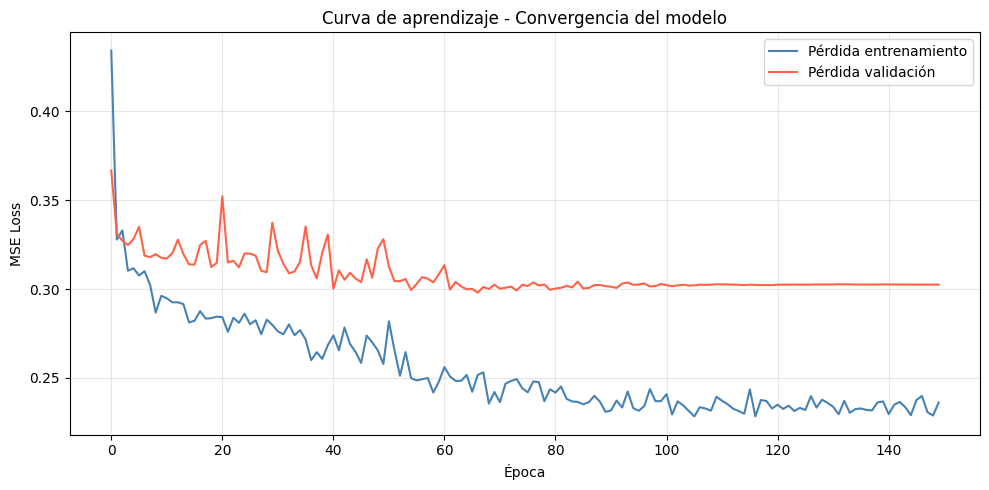

In [15]:
# ─── Gráfica de convergencia (curva de pérdida) ───────────────────────────────
# Nos muestra cómo fue bajando el error a lo largo del entrenamiento
# Si train baja pero test sube → hay overfitting (el modelo memorizó los datos)
# Si ambas bajan juntas → el modelo está aprendiendo bien

plt.figure(figsize=(10, 5))
plt.plot(historico_train, label='Pérdida entrenamiento', color='steelblue')
plt.plot(historico_test,  label='Pérdida validación',    color='tomato')
plt.xlabel('Época')
plt.ylabel('MSE Loss')
plt.title('Curva de aprendizaje - Convergencia del modelo')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

In [16]:
# ─── Métricas de evaluación sobre el conjunto de test ────────────────────────
# Obtenemos todas las predicciones del set de test de una vez

modelo.eval()
with torch.no_grad():
    # Pasamos todo el test de una vez (sin mini-batches, solo para evaluar)
    X_test_tensor = torch.tensor(X_test_norm, dtype=torch.float32).to(device)
    y_pred_norm   = modelo(X_test_tensor).cpu().numpy()

# Des-normalizamos las predicciones para volver a la escala real en dólares
y_pred_real = scaler_y.inverse_transform(y_pred_norm.reshape(-1, 1)).flatten()
y_test_real = y_test   # y_test ya estaba en escala real (no lo normalizamos al cargar)

# ── Métricas ─────────────────────────────────────────────────────────────────
rmse = np.sqrt(mean_squared_error(y_test_real, y_pred_real))
r2   = r2_score(y_test_real, y_pred_real)

print(f"RMSE (Error cuadrático medio): ${rmse:,.0f}")
print(f"  → En promedio nos equivocamos en ${rmse:,.0f} al predecir el precio")
print(f"\nR² Score: {r2:.4f}")
print(f"  → El modelo explica el {r2*100:.1f}% de la varianza en los precios")
print(f"  → Un R²=1.0 sería predicción perfecta, R²=0 sería igual que adivinar el promedio")

RMSE (Error cuadrático medio): $197,305
  → En promedio nos equivocamos en $197,305 al predecir el precio

R² Score: 0.7425
  → El modelo explica el 74.2% de la varianza en los precios
  → Un R²=1.0 sería predicción perfecta, R²=0 sería igual que adivinar el promedio


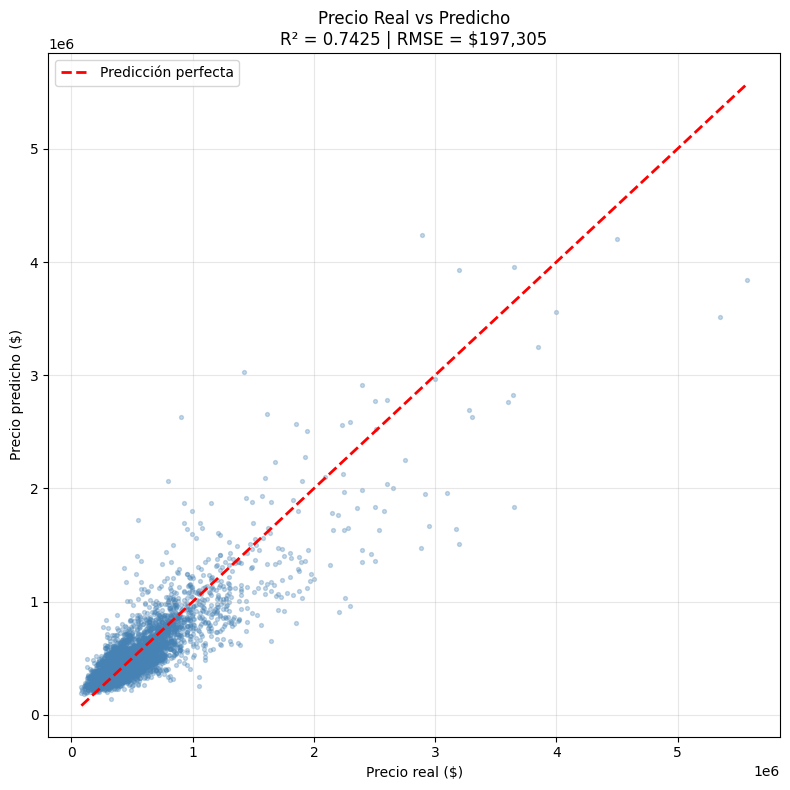

In [17]:
# ─── Gráfica: precios reales vs precios predichos ────────────────────────────
# Si el modelo fuera perfecto, todos los puntos estarían sobre la línea diagonal
# Puntos lejos de la diagonal = errores grandes

plt.figure(figsize=(8, 8))
plt.scatter(y_test_real, y_pred_real, alpha=0.3, s=8, color='steelblue')

# Línea de predicción perfecta
lim_min = min(y_test_real.min(), y_pred_real.min())
lim_max = max(y_test_real.max(), y_pred_real.max())
plt.plot([lim_min, lim_max], [lim_min, lim_max], 'r--', lw=2, label='Predicción perfecta')

plt.xlabel('Precio real ($)')
plt.ylabel('Precio predicho ($)')
plt.title(f'Precio Real vs Predicho\nR² = {r2:.4f} | RMSE = ${rmse:,.0f}')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

## 8. Guardar y Cargar el Modelo
Aplicamos lo aprendido en el cuadernillo 04: guardamos el `state_dict` y demostramos que se puede cargar y usar.

In [18]:
# ─── Guardar el state_dict del modelo (método recomendado) ───────────────────
# El state_dict contiene todos los pesos y bias de la red
# Es el método recomendado porque es eficiente y portable
PATH_FINAL = './regresion_modelo_final.pt'
torch.save(modelo.state_dict(), PATH_FINAL)
print(f"Modelo guardado en: {PATH_FINAL}")

# ─── Cargar el modelo desde el archivo ───────────────────────────────────────
# Para cargar, primero necesitamos instanciar la arquitectura
# Luego cargamos los pesos guardados con load_state_dict
modelo_cargado = RedRegresion(n_entradas=N_FEATURES).to(device)
modelo_cargado.load_state_dict(torch.load(PATH_FINAL, weights_only=True))
modelo_cargado.eval()   # siempre poner en modo evaluación antes de predecir
print("Modelo cargado correctamente ✔")

Modelo guardado en: ./regresion_modelo_final.pt
Modelo cargado correctamente ✔


In [19]:
# ─── Verificar que el modelo cargado predice igual que el original ────────────
with torch.no_grad():
    y_pred_cargado = modelo_cargado(X_test_tensor).cpu().numpy()

y_pred_cargado_real = scaler_y.inverse_transform(y_pred_cargado.reshape(-1, 1)).flatten()

# Comparamos las primeras 5 predicciones de ambos modelos (deben ser idénticas)
print("Predicciones modelo original vs cargado (primeras 5):")
for i in range(5):
    print(f"  Original: ${y_pred_real[i]:>12,.0f}  |  Cargado: ${y_pred_cargado_real[i]:>12,.0f}  |  Real: ${y_test_real[i]:>12,.0f}")

Predicciones modelo original vs cargado (primeras 5):
  Original: $     468,756  |  Cargado: $     468,756  |  Real: $     365,000
  Original: $     691,618  |  Cargado: $     691,618  |  Real: $     865,000
  Original: $   1,013,502  |  Cargado: $   1,013,502  |  Real: $   1,038,000
  Original: $   1,461,653  |  Cargado: $   1,461,653  |  Real: $   1,490,000
  Original: $     619,542  |  Cargado: $     619,542  |  Real: $     711,000


## 9. Predicción de Precio de una Casa Nueva
Demostramos cómo usar el modelo para predecir el precio de una casa con características específicas.

In [20]:
# ─── Predicción de una casa nueva ────────────────────────────────────────────
# Ingresamos las características de una casa hipotética
# El orden debe coincidir con la lista 'features' que definimos al principio

casa_nueva = np.array([[
    3,          # bedrooms:      3 habitaciones
    2.25,       # bathrooms:     2.25 baños
    1800,       # sqft_living:   1800 pies² de vivienda
    7200,       # sqft_lot:      7200 pies² de terreno
    1.0,        # floors:        1 piso
    0,          # waterfront:    sin vista al agua
    0,          # view:          sin vista especial
    3,          # condition:     condición normal
    8,          # grade:         buena calidad de construcción
    1800,       # sqft_above:    1800 sobre el suelo (sin sótano)
    0,          # sqft_basement: sin sótano
    1995,       # yr_built:      construida en 1995
    0           # yr_renovated:  nunca renovada
]])

# ─── Preprocesado: normalizar con el mismo scaler del entrenamiento ───────────
# MUY IMPORTANTE: usamos el scaler que fit-eamos en train, no uno nuevo
# Si usáramos un scaler nuevo, los valores normalizados serían diferentes
casa_norm = scaler_X.transform(casa_nueva)

# Convertir a tensor y mover al dispositivo
casa_tensor = torch.tensor(casa_norm, dtype=torch.float32).to(device)

# ─── Predicción ──────────────────────────────────────────────────────────────
modelo_cargado.eval()
with torch.no_grad():
    precio_norm   = modelo_cargado(casa_tensor).cpu().numpy()
    precio_real   = scaler_y.inverse_transform(precio_norm.reshape(-1, 1)).flatten()[0]

print("=" * 50)
print("        PREDICCIÓN DE PRECIO DE CASA")
print("=" * 50)
print(f"  Habitaciones:    3")
print(f"  Baños:           2.25")
print(f"  Sup. vivienda:   1800 sqft")
print(f"  Sup. terreno:    7200 sqft")
print(f"  Pisos:           1")
print(f"  Año construida:  1995")
print(f"  Grado:           8 (buena calidad)")
print("-" * 50)
print(f"  Precio predicho: ${precio_real:,.0f}")
print("=" * 50)

        PREDICCIÓN DE PRECIO DE CASA
  Habitaciones:    3
  Baños:           2.25
  Sup. vivienda:   1800 sqft
  Sup. terreno:    7200 sqft
  Pisos:           1
  Año construida:  1995
  Grado:           8 (buena calidad)
--------------------------------------------------
  Precio predicho: $391,518


## Resumen

En este cuadernillo aplicamos las herramientas de los cuadernillos 02, 03 y 04 al problema de regresión multivariable del laboratorio anterior:

| Concepto PyTorch | Aplicación en este lab | Cuadernillo origen |
|---|---|---|
| `torch.nn.Module` | Red neuronal `RedRegresion` para predecir precios | 02 |
| `torch.utils.data.Dataset` | `HousePriceDataset` para el CSV de King County | 03 |
| `torch.utils.data.DataLoader` | Mini-batches de 64 casas con shuffle | 03 |
| `torch.save` / `load_state_dict` | Checkpoint del mejor modelo por `val_loss` | 04 |
| `torch.optim.Adam` | Optimizador adaptativo (reemplaza gradiente manual) | 02 |
| `nn.MSELoss` | Función de pérdida (misma J(θ) del lab anterior) | 02 |

**Mejoras respecto al laboratorio anterior:**
- Reemplazamos el gradiente descendiente manual por `Adam` (más eficiente)
- Reemplazamos la ecuación normal por una red neuronal (más flexible)
- Añadimos Dropout para evitar overfitting
- Guardamos automáticamente el mejor modelo durante el entrenamiento
